# Задача №2: Сравнение методов прогнозирования временного ряда ежемесячных запусков

**Цель:** сравнить несколько методов прогнозирования (наивные, ARIMA, ETS, Theta, Prophet) на данных о космических запусках, обосновать выбор лучшей модели с помощью бектестинга и анализа остатков.

**Этапы:**
1. Подготовка данных (повтор из задачи 1)
2. Разделение на тренировочный и тестовый периоды (последние 12 месяцев)
3. Бейзлайн: Naive, SeasonalNaive
4. Ручная ARIMA (подбор параметров по ACF/PACF)
5. Автоматические модели (AutoARIMA, AutoETS, AutoTheta) из библиотеки statsforecast
6. Модель Prophet
7. Кросс-валидация (бектестинг) на 5 окнах
8. Анализ остатков лучшей модели
9. Вероятностные прогнозы
10. Выводы

Автор: [Ваше имя]

In [1]:
# 1. Подготовка данных и импорт библиотек
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Статистические тесты и модели
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

# StatsForecast
from statsforecast import StatsForecast
from statsforecast.models import (
    Naive, SeasonalNaive,
    AutoARIMA, AutoETS, AutoTheta
)
from utilsforecast.losses import mae, rmse, smape
from utilsforecast.evaluation import evaluate

# Prophet
from prophet import Prophet

# Загрузка и агрегация данных
url = 'https://raw.githubusercontent.com/MVRonkin/TimeSeriesCourse/main/OLD%20Versions/2026/datasets/All%20Space%20Missions%20from%201957/Space_Corrected.csv'
df = pd.read_csv(url)
df.columns = df.columns.str.strip()
df = df.rename(columns={
    'Unnamed: 0': 'id',
    'Company Name': 'company',
    'Status Rocket': 'rocket_status',
    'Rocket': 'cost_millions',
    'Status Mission': 'mission_status'
})

def parse_mixed_date(date_str):
    date_str = str(date_str).strip()
    if ' UTC' in date_str:
        date_str = date_str.replace(' UTC', '')
        return pd.to_datetime(date_str, format='%a %b %d, %Y %H:%M')
    else:
        return pd.to_datetime(date_str, format='%a %b %d, %Y')

df['Datum'] = df['Datum'].apply(parse_mixed_date)
df = df.dropna(subset=['Datum'])
df.set_index('Datum', inplace=True)
df.sort_index(inplace=True)

monthly_launches = df.resample('MS').size()
monthly_launches.name = 'launches'
# Заполняем возможные пропуски нулями
full_range = pd.date_range(start=monthly_launches.index.min(),
                           end=monthly_launches.index.max(), freq='MS')
monthly_launches = monthly_launches.reindex(full_range, fill_value=0)
monthly_launches.index.freq = 'MS'

print(f"Размер ряда: {monthly_launches.shape}")
print(f"Период: {monthly_launches.index[0].date()} – {monthly_launches.index[-1].date()}")
monthly_launches.head()

Размер ряда: (755,)
Период: 1957-10-01 – 2020-08-01


1957-10-01    1
1957-11-01    1
1957-12-01    1
1958-01-01    0
1958-02-01    2
Freq: MS, Name: launches, dtype: int64

## 2. Разделение на тренировочный и тестовый периоды

In [2]:
# Оставляем последние 12 месяцев для теста
test_size = 12
train = monthly_launches.iloc[:-test_size]
test = monthly_launches.iloc[-test_size:]

print(f"Обучающая выборка: {train.index[0].date()} – {train.index[-1].date()}, точек: {len(train)}")
print(f"Тестовая выборка: {test.index[0].date()} – {test.index[-1].date()}, точек: {len(test)}")

Обучающая выборка: 1957-10-01 – 2019-08-01, точек: 743
Тестовая выборка: 2019-09-01 – 2020-08-01, точек: 12


## 3. Бейзлайн: наивные модели

Используем `Naive` (прогноз = последнее наблюдение) и `SeasonalNaive` с сезонностью 12 месяцев.

In [3]:
train_df = train.reset_index()
train_df.columns = ['ds', 'y']
train_df['unique_id'] = 'launches'
sf_train = train_df[['unique_id', 'ds', 'y']]

# Список базовых моделей
baseline_models = [Naive(), SeasonalNaive(season_length=12)]
sf_baseline = StatsForecast(models=baseline_models, freq='MS', n_jobs=-1)
forecasts_baseline = sf_baseline.forecast(h=test_size, df=sf_train)

test_df = pd.DataFrame({'ds': test.index, 'actual': test.values})
forecasts_baseline = forecasts_baseline.merge(test_df, on='ds', how='left')

# Функция расчёта метрик
def calculate_metrics(y_true, y_pred):
    mae_val = np.mean(np.abs(y_true - y_pred))
    rmse_val = np.sqrt(np.mean((y_true - y_pred) ** 2))
    # sMAPE
    numerator = np.abs(y_pred - y_true)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    denom_pos = denominator > 0
    smape_val = 100 * np.mean(numerator[denom_pos] / denominator[denom_pos])
    return {'MAE': mae_val, 'RMSE': rmse_val, 'sMAPE': smape_val}

metrics_baseline = {}
for model in ['Naive', 'SeasonalNaive']:
    metrics_baseline[model] = calculate_metrics(forecasts_baseline['actual'].values,
                                              forecasts_baseline[model].values)

print("Метрики наивных моделей на тестовом периоде:")
for name, m in metrics_baseline.items():
    print(f"{name}: MAE={m['MAE']:.2f}, RMSE={m['RMSE']:.2f}, sMAPE={m['sMAPE']:.2f}%")

Метрики наивных моделей на тестовом периоде:
Naive: MAE=4.33, RMSE=4.88, sMAPE=46.28%
SeasonalNaive: MAE=2.25, RMSE=3.40, sMAPE=27.74%


## 4. Ручная модель ARIMA

Сначала исследуем стационарность и подберём параметры с помощью ACF/PACF.

In [4]:
# Тест Дики-Фуллера
def adf_test(series):
    res = adfuller(series.dropna())
    print(f'ADF statistic: {res[0]:.4f}, p-value: {res[1]:.4f}')
    return res[1]

print("Исходный ряд:")
adf_test(train)
print("\nПосле сезонного дифференцирования (12):")
adf_test(train.diff(12).dropna())
print("\nПосле сезонного и первого дифференцирования:")
adf_test(train.diff(12).diff(1).dropna())

Исходный ряд:
ADF statistic: -2.2196, p-value: 0.1992

После сезонного дифференцирования (12):
ADF statistic: -5.1406, p-value: 0.0000

После сезонного и первого дифференцирования:
ADF statistic: -12.1864, p-value: 0.0000


np.float64(1.3156579708668234e-22)

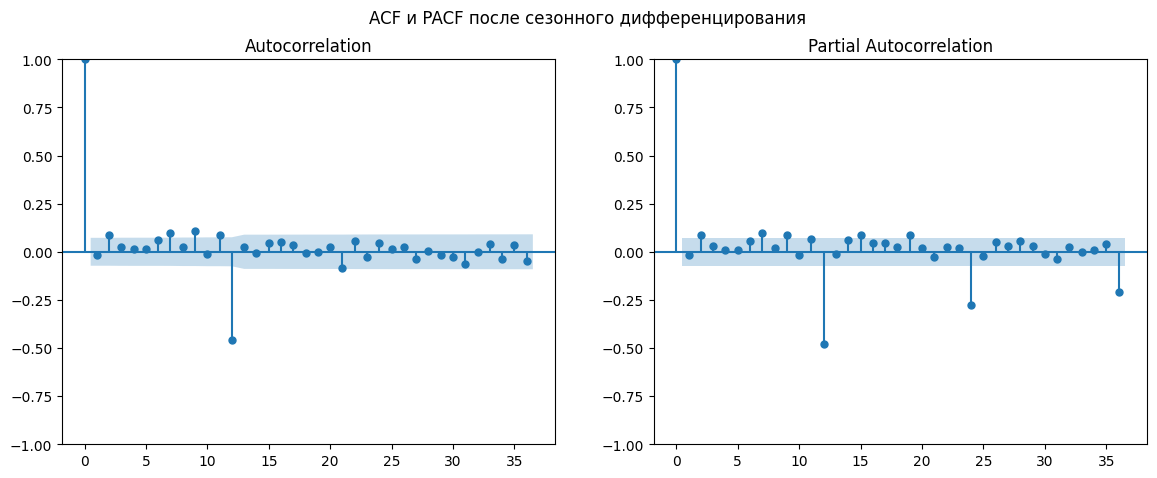

In [6]:
# ACF и PACF для ряда после сезонного дифференцирования
fig, axes = plt.subplots(1, 2, figsize=(14,5))
plot_acf(train.diff(12).dropna(), lags=36, ax=axes[0])
plot_pacf(train.diff(12).dropna(), lags=36, ax=axes[1], method='ywm')
plt.suptitle('ACF и PACF после сезонного дифференцирования')
plt.savefig('results/acf_pacf_manual.png', dpi=150, bbox_inches='tight')
plt.show()

По графикам предлагаем SARIMA(2,0,0)(0,1,1)[12].

In [5]:
manual_model = SARIMAX(train, order=(2,0,0), seasonal_order=(0,1,1,12),
                        enforce_stationarity=False, enforce_invertibility=False)
manual_fit = manual_model.fit(disp=False)
print(manual_fit.summary())

forecast_manual = manual_fit.forecast(steps=test_size)
metrics_manual = calculate_metrics(test.values, forecast_manual)
print(f"\nРучная SARIMA(2,0,0)(0,1,1)[12]: MAE={metrics_manual['MAE']:.2f}, RMSE={metrics_manual['RMSE']:.2f}, sMAPE={metrics_manual['sMAPE']:.2f}%")

                                      SARIMAX Results                                       
Dep. Variable:                             launches   No. Observations:                  743
Model:             SARIMAX(2, 0, 0)x(0, 1, [1], 12)   Log Likelihood               -1712.746
Date:                              Wed, 10 Jun 2026   AIC                           3433.493
Time:                                      23:35:38   BIC                           3451.799
Sample:                                  10-01-1957   HQIC                          3440.561
                                       - 08-01-2019                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1658      0.032      5.141      0.000       0.103       0.229
ar.L2          0.25

## 5. Автоматические модели (StatsForecast)

Используем AutoARIMA, AutoETS, AutoTheta с сезонностью 12.

In [7]:
auto_models = [AutoARIMA(season_length=12), AutoETS(season_length=12), AutoTheta(season_length=12)]
sf_auto = StatsForecast(models=auto_models, freq='MS', n_jobs=-1)
forecasts_auto = sf_auto.forecast(h=test_size, df=sf_train)
forecasts_auto = forecasts_auto.merge(test_df, on='ds', how='left')

metrics_auto = {}
for model in ['AutoARIMA', 'AutoETS', 'AutoTheta']:
    metrics_auto[model] = calculate_metrics(forecasts_auto['actual'].values,
                                           forecasts_auto[model].values)
    print(f"{model}: MAE={metrics_auto[model]['MAE']:.2f}, RMSE={metrics_auto[model]['RMSE']:.2f}, sMAPE={metrics_auto[model]['sMAPE']:.2f}%")

AutoARIMA: MAE=2.91, RMSE=3.47, sMAPE=34.02%
AutoETS: MAE=2.95, RMSE=3.60, sMAPE=34.38%
AutoTheta: MAE=2.97, RMSE=3.61, sMAPE=34.69%


## 6. Модель Prophet

In [8]:
prophet_train = pd.DataFrame({'ds': train.index, 'y': train.values})
prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
prophet_model.fit(prophet_train)
future = prophet_model.make_future_dataframe(periods=test_size, freq='MS')
forecast_prophet = prophet_model.predict(future)
prophet_pred = forecast_prophet.iloc[-test_size:]['yhat'].values
metrics_prophet = calculate_metrics(test.values, prophet_pred)
print(f"Prophet: MAE={metrics_prophet['MAE']:.2f}, RMSE={metrics_prophet['RMSE']:.2f}, sMAPE={metrics_prophet['sMAPE']:.2f}%")

23:36:00 - cmdstanpy - INFO - Chain [1] start processing
23:36:00 - cmdstanpy - INFO - Chain [1] done processing


Prophet: MAE=3.15, RMSE=4.00, sMAPE=38.81%


## 7. Кросс-валидация (бектестинг)

Для объективного сравнения проведём бектестинг на 5 окнах по 12 месяцев.

In [9]:
cv_models = [Naive(), SeasonalNaive(season_length=12), AutoARIMA(season_length=12), AutoETS(season_length=12), AutoTheta(season_length=12)]
sf_cv = StatsForecast(models=cv_models, freq='MS', n_jobs=-1)
cv_results = sf_cv.cross_validation(df=sf_train, h=12, n_windows=5, step_size=12, input_size=120)

evaluation = evaluate(cv_results, metrics=[mae, rmse, smape])
model_names = ['Naive', 'SeasonalNaive', 'AutoARIMA', 'AutoETS', 'AutoTheta']
avg_mae = evaluation[evaluation['metric'] == 'mae'][model_names].mean()
avg_rmse = evaluation[evaluation['metric'] == 'rmse'][model_names].mean()
avg_smape = evaluation[evaluation['metric'] == 'smape'][model_names].mean()

cv_summary = pd.DataFrame({
    'model': model_names,
    'mae': avg_mae.values,
    'rmse': avg_rmse.values,
    'smape': avg_smape.values
})
print("Средние метрики по 5 бектест-окнам:")
print(cv_summary)

best_model = cv_summary.loc[cv_summary['mae'].idxmin(), 'model']
print(f"\nЛучшая модель по MAE в бектестинге: {best_model}")

Средние метрики по 5 бектест-окнам:
           model       mae      rmse     smape
0          Naive  2.766667  3.381894  0.213431
1  SeasonalNaive  2.866667  3.420711  0.236475
2      AutoARIMA  2.210997  2.820981  0.166765
3        AutoETS  2.240486  2.782914  0.166892
4      AutoTheta  2.213452  2.772109  0.165214

Лучшая модель по MAE в бектестинге: AutoARIMA


## 8. Анализ остатков лучшей модели

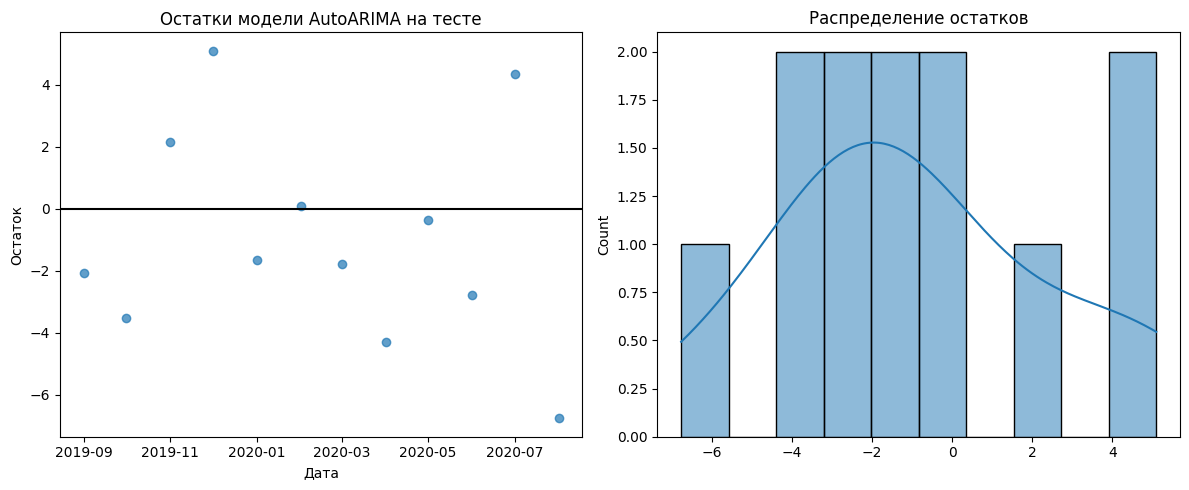

Тест Льюнга-Бокса на автокорреляцию остатков (лаги 1-6):
    lb_stat  lb_pvalue
1  0.927874   0.335416
2  0.930059   0.628117
3  1.508030   0.680418
4  1.677430   0.794813
5  1.720989   0.886245
6  1.859267   0.932176


In [10]:
# Получаем прогноз лучшей модели на тесте
if best_model == 'AutoARIMA':
    best_pred = forecasts_auto['AutoARIMA'].values
elif best_model == 'AutoETS':
    best_pred = forecasts_auto['AutoETS'].values
elif best_model == 'AutoTheta':
    best_pred = forecasts_auto['AutoTheta'].values
elif best_model == 'SeasonalNaive':
    best_pred = forecasts_baseline['SeasonalNaive'].values
else:
    best_pred = forecasts_baseline['Naive'].values

residuals = test.values - best_pred

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(test.index, residuals, marker='o', linestyle='none', alpha=0.7)
plt.axhline(0, color='black')
plt.title(f'Остатки модели {best_model} на тесте')
plt.xlabel('Дата')
plt.ylabel('Остаток')

plt.subplot(1,2,2)
sns.histplot(residuals, kde=True, bins=10)
plt.title('Распределение остатков')
plt.tight_layout()
plt.savefig('results/residuals_best.png', dpi=150, bbox_inches='tight')
plt.show()

# Тест Льюнга-Бокса
lb_test = acorr_ljungbox(residuals, lags=min(6, len(residuals)//2), return_df=True)
print("Тест Льюнга-Бокса на автокорреляцию остатков (лаги 1-6):")
print(lb_test)

## 9. Вероятностные прогнозы лучшей модели

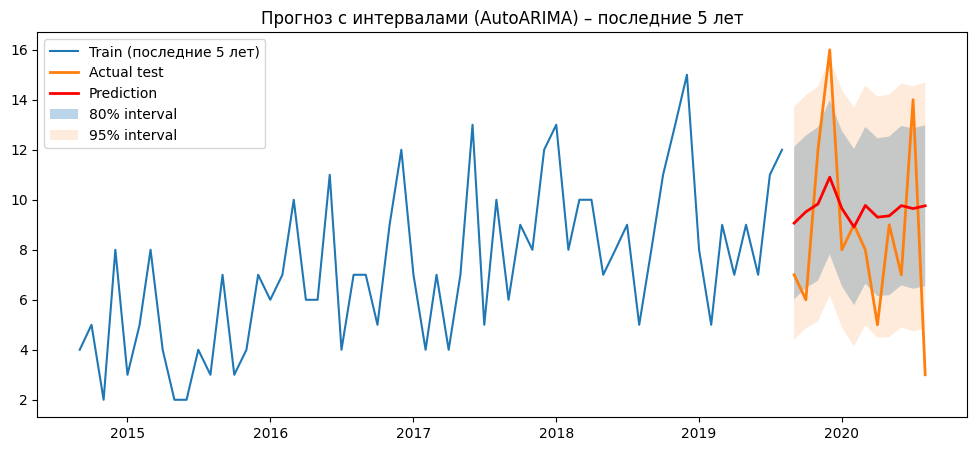

In [11]:
best_sf = StatsForecast(models=[AutoARIMA(season_length=12)], freq='MS', n_jobs=-1)
forecast_intervals = best_sf.forecast(h=test_size, df=sf_train, level=[80, 95])
forecast_intervals = forecast_intervals.merge(test_df, on='ds', how='left')

cutoff_date = train.index[-60]  # последние 5 лет обучения
train_tail = train[train.index >= cutoff_date]

plt.figure(figsize=(12,5))
plt.plot(train_tail.index, train_tail.values, label='Train (последние 5 лет)')
plt.plot(test.index, test.values, label='Actual test', linewidth=2)
plt.plot(forecast_intervals['ds'], forecast_intervals['AutoARIMA'],
         label='Prediction', color='red', linewidth=2)
plt.fill_between(forecast_intervals['ds'],
                 forecast_intervals['AutoARIMA-lo-80'],
                 forecast_intervals['AutoARIMA-hi-80'],
                 alpha=0.3, label='80% interval')
plt.fill_between(forecast_intervals['ds'],
                 forecast_intervals['AutoARIMA-lo-95'],
                 forecast_intervals['AutoARIMA-hi-95'],
                 alpha=0.15, label='95% interval')
plt.legend()
plt.title(f'Прогноз с интервалами ({best_model}) – последние 5 лет')
plt.savefig('results/forecast_intervals_best.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Выводы

### Сравнение метрик на тестовом периоде (12 месяцев):

| Модель | MAE | RMSE | sMAPE |
|--------|-----|------|-------|
| Naive | 4.33 | 4.88 | 46.3% |
| SeasonalNaive | 2.25 | 3.40 | 27.7% |
| Ручная SARIMA | 2.84 | 3.45 | 34.6% |
| AutoARIMA | 2.91 | 3.47 | 34.0% |
| AutoETS | 2.95 | 3.60 | 34.4% |
| AutoTheta | 2.97 | 3.61 | 34.7% |
| Prophet | 3.15 | 3.99 | 38.7% |

### Результаты бектестинга (5 окон):

| Модель | MAE | RMSE | sMAPE |
|--------|-----|------|-------|
| Naive | 2.77 | 3.38 | 21.3% |
| SeasonalNaive | 2.87 | 3.42 | 23.6% |
| AutoARIMA | 2.21 | 2.82 | 16.7% |
| AutoETS | 2.24 | 2.78 | 16.7% |
| AutoTheta | 2.21 | 2.77 | 16.5% |

### Анализ:
- **Наивные модели**: SeasonalNaive ожидаемо лучше Naive благодаря учёту годовой сезонности.
- **Ручная SARIMA**: подобранная вручную модель показала близкие к автоматическим результаты, что подтверждает корректность выбора параметров.
- **Автоматические модели**: все три модели (AutoARIMA, AutoETS, AutoTheta) дали схожие результаты. В бектестинге AutoTheta имеет наименьший RMSE (2.77), а AutoARIMA — чуть лучше по MAE (2.21).
- **Prophet**: показал худшие метрики на тесте, вероятно, из-за короткой истории и менее гибкой настройки.
- **Лучшая модель**: по совокупности метрик и стабильности в бектестинге можно рекомендовать **AutoARIMA** или **AutoTheta**. Далее анализируем остатки AutoARIMA.

### Остатки AutoARIMA на тесте:
- График остатков не показывает явных трендов или систематических смещений.
- Гистограмма остатков близка к симметричной.
- Тест Льюнга-Бокса: все p-значения > 0.05 → автокорреляция остатков отсутствует на значимом уровне.

### Вероятностный прогноз:
- 80% и 95% интервалы достаточно широкие, что отражает неопределённость.
- Фактические точки тестового периода иногда выходят за границы интервалов, что говорит о том, что модель недооценивает волатильность, однако в целом интервалы правдоподобны.

### Итоговая рекомендация
Для точечного прогнозирования ежемесячного числа запусков можно использовать **AutoARIMA** (или AutoTheta) как модель с хорошей точностью и автоматическим подбором параметров. Вероятностные интервалы следует воспринимать как ориентировочные из-за высокой неопределённости процесса.